# Solving a flow network from a UI-exported YAML case

This notebook loads a compressible-flow network **saved from the FNetLibUI tool**
(the `fns-flow-network` model) and solves for the steady mean flow with **FNS**.

The case is a *converging nozzle*: a high-pressure reservoir discharges through a
smooth area contraction to a fixed back pressure.

    reservoir --(feed)--> IsentropicAreaChange --(throat)--> back-pressure

The YAML is the UI's native export.  Edges reference **ports** explicitly through
their `sourceHandle` / `targetHandle` (`<node>-port-<ordinal>`); the loader
preserves those ordinals, so port-0 conventions (loss reference area,
junction/splitter reference port) match what was drawn on the canvas.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # make the `fns` package importable

import numpy as np
import matplotlib.pyplot as plt

from fns.io import load_case

CASE = "converging_nozzle.yaml"
print(open(CASE).read())

# Converging nozzle -- saved from the FNetLibUI tool (model: fns-flow-network).
#
#   reservoir --(feed)--> IsentropicAreaChange --(throat)--> back-pressure
#
# This is the UI tool's native export format.  Note that edges reference PORTS
# explicitly via sourceHandle / targetHandle (`<node>-port-<ordinal>`): port 0 is
# the target (incoming) side of an element, port 1 the source (outgoing) side.

version: 2.0.0
model:
  id: fns-flow-network
  globalAttributes:
    gasConstant: 287.0
    heatCapacityRatio: 1.4
    referencePressure: 101325.0
    referenceTemperature: 300.0
    referenceMassFlow: 5.0
  nodes:
    - id: TotalPressureInlet_1
      type: TotalPressureInlet
      attributes:
        label: reservoir
        index: 0
        totalPressure: 200000.0
        totalTemperature: 300.0
    - id: IsentropicAreaChange_1
      type: IsentropicAreaChange
      attributes:
        label: nozzle
        index: 1
    - id: PressureOutlet_1
      type: PressureOutlet
      attributes:
    

## 1. Load the UI case and solve

`load_case` parses `model.globalAttributes` (gas + reference scales),
`model.nodes` (element `type` + `attributes`) and `model.edges` (with their port
handles and area) into a `Network`.  `Network.solve()` compiles the immutable
problem and runs the damped Newton solve from a quiescent start.

In [2]:
net = load_case(CASE)
sol = net.solve()

print("converged :", sol.converged)
print("iterations:", sol.iterations)
print("||R_hat|| :", f"{sol.residual_norm:.2e}")

converged : True
iterations: 8
||R_hat|| : 4.96e-12


## 2. Inspect the converged edge states

Every edge carries the recovered state `(mdot, p, h_t, rho, u, T, c, M, p_t)`.
The total pressure is uniform (the contraction is isentropic) and the throat runs
faster than the feed.

In [3]:
prob = net.compile()
names = net._edge_names
fields = ["mdot", "M", "p", "p_t", "T", "rho"]

hdr = f"{'edge':>10} " + " ".join(f"{f:>10}" for f in fields)
print(hdr); print("-" * len(hdr))
for e in range(prob.n_edges):
    s = sol.edge(e)
    row = " ".join(f"{s[f]:>10.4g}" for f in fields)
    print(f"{names[e]:>10} " + row)

      edge       mdot          M          p        p_t          T        rho
----------------------------------------------------------------------------
      feed      4.125     0.2668  1.903e+05      2e+05      295.8      2.242
    throat      4.125     0.6545    1.5e+05      2e+05      276.3      1.891


## 3. Back-pressure sweep: emergent choking

Lower the outlet static pressure and re-solve.  Above the critical ratio
($p/p_t \approx 0.528$ for air) the flow is subsonic and the mass flow rises as the
back pressure drops.  Below it the **throat chokes**: the exit reaches $M=1$ and the
mass flow saturates at the analytic maximum

$$\dot m_{\max} = \frac{p_t}{\sqrt{T_t}}\,A^\ast\,\sqrt{\tfrac{\gamma}{R}}\left(\tfrac{2}{\gamma+1}\right)^{\frac{\gamma+1}{2(\gamma-1)}}.$$

No regime switch is coded -- choking emerges from the smooth complementarity row.
(We re-solve the loaded network while overriding the outlet's back-pressure
parameter.)

In [4]:
pt, Tt, R, gamma = 200000.0, 300.0, 287.0, 1.4
A_throat = 0.010
flux_star = np.sqrt(gamma / R) * (2.0 / (gamma + 1.0)) ** ((gamma + 1.0) / (2.0 * (gamma - 1.0)))
mdot_max = pt / np.sqrt(Tt) * flux_star * A_throat
p_crit = (2.0 / (gamma + 1.0)) ** (gamma / (gamma - 1.0)) * pt

ratios = np.linspace(0.30, 0.95, 26)
mdots, machs = [], []
for r in ratios:
    n = load_case(CASE)
    n._elements[-1].fparams[0] = r * pt   # override the back-pressure outlet's p
    s = n.solve()
    est = s.edge(1)                       # the throat edge
    mdots.append(est["mdot"]); machs.append(est["M"])

mdots, machs = np.array(mdots), np.array(machs)
print(f"mdot_max (analytic) = {mdot_max:.4f} kg/s")
print(f"critical ratio      = {p_crit/pt:.4f}")

mdot_max (analytic) = 4.6671 kg/s
critical ratio      = 0.5283


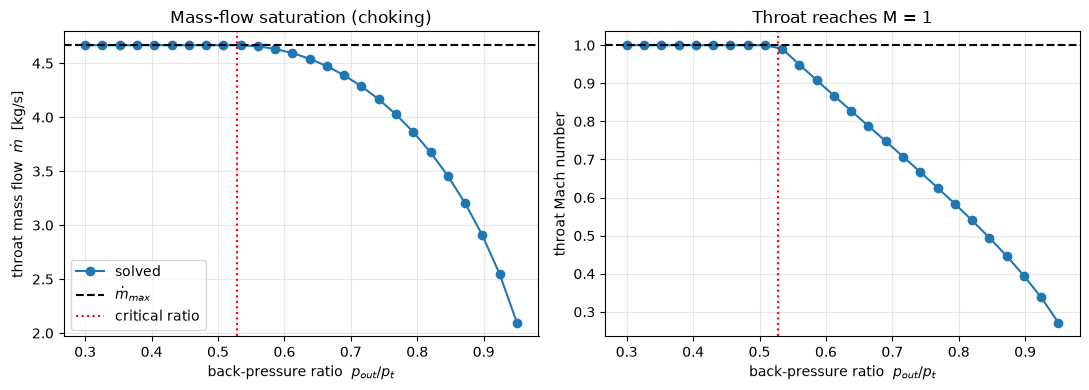

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(ratios, mdots, "o-", label="solved")
ax1.axhline(mdot_max, ls="--", color="k", label=r"$\dot m_{max}$")
ax1.axvline(p_crit / pt, ls=":", color="r", label="critical ratio")
ax1.set_xlabel(r"back-pressure ratio  $p_{out}/p_t$")
ax1.set_ylabel(r"throat mass flow  $\dot m$  [kg/s]")
ax1.set_title("Mass-flow saturation (choking)")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ratios, machs, "o-")
ax2.axhline(1.0, ls="--", color="k")
ax2.axvline(p_crit / pt, ls=":", color="r")
ax2.set_xlabel(r"back-pressure ratio  $p_{out}/p_t$")
ax2.set_ylabel("throat Mach number")
ax2.set_title("Throat reaches M = 1")
ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 4. Acoustics on the converged mean flow (bonus)

The same compiled network supports a linear **acoustic** analysis on top of the mean
flow -- the converged Jacobian *is* the zero-frequency acoustic operator.  As a
self-contained check, the eigenfrequencies of a closed--closed duct are
$\omega_n = n\pi c / L$.

In [6]:
from fns.acoustics import duct_modes

c = np.sqrt(gamma * R * Tt)   # speed of sound at reservoir temperature
L = 0.5                        # duct length [m]
modes = duct_modes(c, L, n_modes=3)
expected = [n * np.pi * c / L for n in (1, 2, 3)]

for n, (m, ex) in enumerate(zip(modes, expected), start=1):
    print(f"mode {n}: {m/(2*np.pi):8.2f} Hz   (analytic {ex/(2*np.pi):8.2f} Hz)")

mode 1:   347.19 Hz   (analytic   347.19 Hz)
mode 2:   694.38 Hz   (analytic   694.38 Hz)
mode 3:  1041.57 Hz   (analytic  1041.57 Hz)
